Key Concepts Explained
LangGraph State: The EmailState TypedDict defines what data flows through the workflow

Nodes: send_email_node is a single step in the workflow

Edges: Connect nodes (here send_email → END)

Environment Variables: Securely store sensitive data like API keys

Error Handling: Captures and reports SendGrid API errors

In [1]:
import os
from dotenv import load_dotenv
from sendgrid import SendGridAPIClient
from sendgrid.helpers.mail import Mail
from langgraph.graph import StateGraph, END
from typing import TypedDict

# Load environment variables
load_dotenv()

True

In [2]:

SENDGRID_API_KEY = os.getenv("SENDGRID_API_KEY")
try:
    sg = SendGridAPIClient(SENDGRID_API_KEY)
    
    # Create a properly formatted email
    message = Mail(
        from_email='pashaajaz@gmail.com',
        to_emails='pashaajaz@gmail.com',
        subject='Your Subject Here',
        html_content='<strong>Your HTML content here</strong>'
    )
    
    response = sg.send(message)
    print(f"Email sent! Status code: {response.status_code}")
    
except Exception as e:
    print("SendGrid error body:", getattr(e, "body", e))
    raise

Email sent! Status code: 202


In [3]:
"""
================================================================================
EMAIL SENDING MODULE WITH LANGGRAPH
================================================================================
This module demonstrates how to integrate SendGrid email sending capabilities
into a LangGraph workflow. It defines a state machine that processes email
requests and sends them using the SendGrid API.

KEY COMPONENTS:
1. EmailState: Defines the data structure for email workflow
2. send_email_node: The main function that sends emails
3. LangGraph workflow: Builds and executes the email sending pipeline

DEPENDENCIES:
- sendgrid: For email delivery
- langgraph: For workflow orchestration
- python-dotenv: For environment variable management
================================================================================
"""

# ============================================================================
# IMPORTS
# ============================================================================
import os  # Operating system interface for environment variables
from typing import TypedDict  # Type hints for better code clarity
from dotenv import load_dotenv  # Load environment variables from .env file
from sendgrid import SendGridAPIClient  # Main SendGrid client
from sendgrid.helpers.mail import Mail  # Email construction helper
from langgraph.graph import StateGraph, END  # LangGraph workflow components

# ============================================================================
# ENVIRONMENT SETUP
# ============================================================================
# Load environment variables from .env file
# This must be called before accessing any environment variables
load_dotenv()

# ============================================================================
# STATE DEFINITION
# ============================================================================
class EmailState(TypedDict):
    """
    Defines the structure of data that flows through the email workflow.
    
    This TypedDict ensures type safety and provides clear documentation
    of what data is expected at each step of the workflow.
    
    Attributes:
        to_email (str): Recipient's email address
        subject (str): Email subject line
        content (str): HTML content of the email
        sendgrid_api_key (str, optional): API key (can also come from env)
        email_sent (bool, optional): Status flag for successful sending
        email_response (dict, optional): Response data from SendGrid
    """
    to_email: str
    subject: str
    content: str
    sendgrid_api_key: str  # Optional: pass via state
    # Additional fields can be added as needed

# ============================================================================
# NODE FUNCTION: SEND EMAIL
# ============================================================================
def send_email_node(state: EmailState):
    """
    LangGraph node function that sends an email using SendGrid.
    
    This function is called as part of the LangGraph workflow. It:
    1. Retrieves the SendGrid API key (from state or environment)
    2. Constructs the email message
    3. Sends it via SendGrid API
    4. Updates the state with the result
    
    Args:
        state (EmailState): Current state of the workflow
        
    Returns:
        EmailState: Updated state with email sending results
        
    Raises:
        ValueError: If API key is not found
        Exception: If email sending fails (with detailed error info)
    """
    
    # --- Step 1: Get API Key ---
    # Priority: Use API key from state first, fallback to environment variable
    # This flexibility allows dynamic API keys per workflow run
    api_key = state.get("sendgrid_api_key") or os.getenv("SENDGRID_API_KEY")
    
    # Validate that we have an API key before proceeding
    if not api_key:
        raise ValueError("SendGrid API key not found. Please set SENDGRID_API_KEY in .env or pass via state.")
    
    try:
        # --- Step 2: Initialize SendGrid Client ---
        # Create the SendGrid client with the retrieved API key
        sg = SendGridAPIClient(api_key)
        
        # --- Step 3: Create Email Message ---
        # Build the email using SendGrid's Mail helper class
        # From email: Use environment variable with fallback default
        # To email: From state
        # Subject: From state
        # Content: HTML formatted content from state
        message = Mail(
            from_email=os.getenv("SENDGRID_FROM_EMAIL", "pashaajaz@gmail.com"),
            to_emails=state["to_email"],
            subject=state["subject"],
            html_content=state["content"]
        )
        
        # --- Step 4: Send Email ---
        # Make the API call to SendGrid
        # This will raise an exception if the send fails
        response = sg.send(message)
        
        # --- Step 5: Log Success ---
        # Status 202 means the email was accepted for delivery
        print(f"✅ Email sent successfully! Status: {response.status_code}")
        
        # --- Step 6: Update State with Results ---
        # Mark email as sent and store response details for later use
        state["email_sent"] = True
        state["email_response"] = {
            "status_code": response.status_code,
            "headers": dict(response.headers)  # Contains message ID and other metadata
        }
        
        # Return the updated state for the next node in the workflow
        return state
        
    except Exception as e:
        # --- Error Handling ---
        # Log the error with detailed information
        print(f"❌ Failed to send email: {e}")
        
        # SendGrid errors often have a 'body' attribute with detailed info
        # Extract and log this for debugging
        if hasattr(e, 'body'):
            print(f"Error details: {e.body}")
        
        # Re-raise the exception to stop the workflow
        # This ensures the workflow fails visibly
        raise

# ============================================================================
# BUILD LANGGRAPH WORKFLOW
# ============================================================================
# This section constructs the workflow graph that will orchestrate
# the email sending process.

# Initialize the state graph with our EmailState type
# This tells LangGraph what kind of data to expect
graph = StateGraph(EmailState)

# Add our email sending function as a node in the graph
# The node name 'send_email' will be used to reference this step
graph.add_node("send_email", send_email_node)

# Set the entry point (first node to execute)
# When the workflow starts, it will call send_email_node
graph.set_entry_point("send_email")

# Add an edge from send_email to END
# This means after sending the email, the workflow completes
graph.add_edge("send_email", END)

# ============================================================================
# COMPILE WORKFLOW
# ============================================================================
# Compile the graph into a runnable application
# This validates the graph structure and prepares it for execution
app = graph.compile()

# ============================================================================
# EXECUTE WORKFLOW
# ============================================================================
# Test the workflow by invoking it with a sample email
# This simulates a real run of the workflow

print("\n" + "="*60)
print("🚀 STARTING EMAIL WORKFLOW")
print("="*60 + "\n")

# Invoke the workflow with initial state data
# This is where we provide the email details for this run
result = app.invoke({
    "to_email": "pashaajaz@gmail.com",  # Recipient email
    "subject": "Test Email from LangGraph",  # Email subject
    "content": "<h1>Hello from LangGraph!</h1><p>This is a test.</p>",  # HTML content
    # Note: sendgrid_api_key is optional here since we're using environment variable
})

# The result contains the final state after workflow completion
# This includes any updates made by the node functions

print("\n" + "="*60)
print("✅ WORKFLOW COMPLETED SUCCESSFULLY")
print("="*60)

# Display the final result summary
print("\n📊 Final State Summary:")
print(f"   Email sent: {result.get('email_sent', False)}")
if result.get('email_response'):
    print(f"   Status code: {result['email_response']['status_code']}")
    print(f"   Message ID: {result['email_response']['headers'].get('x-message-id', 'N/A')}")

print("\n" + "="*60)


🚀 STARTING EMAIL WORKFLOW

✅ Email sent successfully! Status: 202

✅ WORKFLOW COMPLETED SUCCESSFULLY

📊 Final State Summary:
   Email sent: False



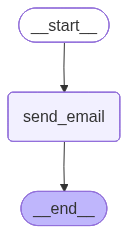

In [4]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization unavailable in this environment:", e)
    print(app.get_graph().draw_mermaid())